# DeepLabV3+ Farmland Boundary Segmentation
Optimized training pipeline: ResNet101 backbone, Dice+BCE loss, Albumentations augmentations, train/val split, LR scheduler, best-checkpoint saving, 1024x1024 training, 200 epochs, prediction, overlays and metrics.

In [ ]:
# pip install segmentation-models-pytorch albumentations opencv-python matplotlib tqdm --quiet

In [1]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import xml.etree.ElementTree as ET

In [2]:
# ----------------- DEVICE & SEED -----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
# ===== OPTIMIZED FOR FAST TRAINING (ResNet34, 512px, 25 epochs, Early Stopping) =====
BASE = r'D:/farmland boundary'
TRAIN1_IMAGES = os.path.join(BASE, 'New folder', 'Train', 'farmlands')
TRAIN1_XML = os.path.join(BASE, 'New folder', 'Train', 'boundary mask', 'Train1_annotations.xml')
TRAIN2_IMAGES = os.path.join(BASE, 'New folder', 'Train 2', 'images')
TRAIN2_XML = os.path.join(BASE, 'New folder', 'Train 2', 'boundarydet', 'Train2_annotations.xml')
MASK_FOLDER = os.path.join(BASE, 'all_boundary_masks')
PREDICT_IMAGES = os.path.join(BASE, 'New folder', 'images')
PREDICTION_FOLDER = os.path.join(BASE, 'deeplab_predictions')
OVERLAY_FOLDER = os.path.join(BASE, 'overlay_predictions')
MODEL_PATH = os.path.join(BASE, 'deeplabv3plus_resnet34_best.pth')
os.makedirs(PREDICTION_FOLDER, exist_ok=True)
os.makedirs(OVERLAY_FOLDER, exist_ok=True)

# FAST TRAINING SETTINGS
IMAGE_SIZE = 512  # reduced from 1024 → 4x faster
BATCH_SIZE = 4    # increased from 2 → faster epochs
EPOCHS = 25       # reduced from 200 → 8x fewer epochs
LEARNING_RATE = 1e-3  # higher LR for faster convergence
NUM_WORKERS = 0   # Windows compatible
EARLY_STOPPING_PATIENCE = 5  # stop if no improvement

In [4]:
def normalize_name(name):
    name = os.path.splitext(name)[0]
    name = name.lower().replace('_pred', '').replace('- copy', '').replace(' ', '').strip()
    return name

In [5]:
def parse_xml_to_masks(xml_path, images_folder, out_mask_folder, image_size):
    # Attempts to parse simple XML annotations containing polygons and create binary masks.
    # This is a best-effort parser for common formats; inspect your XML if results look wrong.
    os.makedirs(out_mask_folder, exist_ok=True)
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print('Failed to parse XML:', xml_path, e)
        return
    # Build mapping image->polygons
    annotations = {}
    for item in root.findall('.//object') + root.findall('.//annotation') + root.findall('.//image'):
        # try common patterns
        name = None
        pts = []
        # name fields
        for tag in ['filename', 'name', 'imageName', 'image']:
            t = item.find(tag)
            if t is not None and t.text:
                name = t.text
                break
        # points / polygon fields (generic search)
        for poly in item.findall('.//polygon') + item.findall('.//points') + item.findall('.//shape'):
            # collect x,y pairs
            xs = [float(x.text) for x in poly.findall('.//x')] if poly.findall('.//x') else []
            ys = [float(y.text) for y in poly.findall('.//y')] if poly.findall('.//y') else []
            if xs and ys and len(xs)==len(ys):
                pts.append(list(zip(xs, ys)))
            else:
                # look for 'points' attribute like 'x1,y1 x2,y2' or 'x1,y1; x2,y2'
                pts_text = poly.text or ''
                if pts_text:
                    pts_pairs = []
                    for pair in pts_text.replace(';', ' ').split():
                        if ',' in pair:
                            a,b = pair.split(',')
                            try:
                                pts_pairs.append((float(a), float(b)))
                            except:
                                pass
                    if pts_pairs:
                        pts.append(pts_pairs)
        # fallback: coordinates under 'points' with 'pt' children
        if not pts:
            for pts_tag in item.findall('.//pts') + item.findall('.//points'):
                local = []
                for pt in pts_tag.findall('.//pt'):
                    x = pt.find('x')
                    y = pt.find('y')
                    if x is not None and y is not None:
                        try:
                            local.append((float(x.text), float(y.text)))
                        except: pass
                if local:
                    pts.append(local)
        if name and pts:
            annotations.setdefault(name, []).extend(pts)
    # Create masks for each annotated image
    for img_name, polygons in annotations.items():
        # locate image file
        key = normalize_name(img_name)
        candidates = [p for p in glob(os.path.join(images_folder, '*')) if normalize_name(os.path.basename(p))==key]
        if not candidates:
            continue
        img_path = candidates[0]
        img = cv2.imread(img_path)
        if img is None:
            continue
        h,w = img.shape[:2]
        mask = np.zeros((h,w), dtype=np.uint8)
        for poly in polygons:
            pts = np.array([[int(x), int(y)] for (x,y) in poly], dtype=np.int32)
            if pts.shape[0]>=3:
                cv2.fillPoly(mask, [pts], 255)
        out_name = os.path.splitext(os.path.basename(img_path))[0] + '.png'
        out_path = os.path.join(out_mask_folder, out_name)
        cv2.imwrite(out_path, mask)
    print('Parsed masks written to', out_mask_folder)

In [6]:
# If no masks folder exists, try to parse provided XMLs to create masks (best-effort)
if not os.path.exists(MASK_FOLDER) or len(glob(os.path.join(MASK_FOLDER, '*.png'))) == 0:
    print('No masks found in', MASK_FOLDER)
    MASK_FOLDER = os.path.join(BASE, 'generated_masks')
    # try parse both xmls if they exist
    if os.path.exists(TRAIN1_XML):
        parse_xml_to_masks(TRAIN1_XML, TRAIN1_IMAGES, MASK_FOLDER, IMAGE_SIZE)
    if os.path.exists(TRAIN2_XML):
        parse_xml_to_masks(TRAIN2_XML, TRAIN2_IMAGES, MASK_FOLDER, IMAGE_SIZE)
else:
    print('Using masks in', MASK_FOLDER)

Using masks in D:/farmland boundary\all_boundary_masks


In [7]:
class FarmlandDataset(Dataset):
    def __init__(self, samples, transforms=None):
        self.samples = samples
        self.transforms = transforms
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            mask = np.zeros(img.shape[:2], dtype=np.uint8)
        # normalize to 0/1
        mask = (mask > 127).astype('uint8')
        if self.transforms:
            aug = self.transforms(image=img, mask=mask)
            img = aug['image']
            mask = aug['mask']
            # handle image output (could be numpy array or torch.Tensor)
        if isinstance(img, np.ndarray):
            img = img.astype('float32') / 255.0
            img = np.transpose(img, (2,0,1))
            img = torch.from_numpy(img)
        elif isinstance(img, torch.Tensor):
            # ToTensorV2 may already have converted and normalized the image
            if img.dtype == torch.uint8:
                img = img.float() / 255.0
            else:
                img = img.float()
        # handle mask output (could be numpy array or torch.Tensor)
        if isinstance(mask, np.ndarray):
            mask = (mask > 0).astype('float32')
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        elif isinstance(mask, torch.Tensor):
            # mask might be HxW or 1xHxW -- normalize to 1xHxW float tensor
            if mask.dim() == 3:
                mask = mask.float()
            elif mask.dim() == 2:
                mask = mask.unsqueeze(0).float()
            else:
                mask = mask.float()
        return img, mask

In [8]:
# ----------------- BUILD TRAIN/VAL SAMPLES -----------------
# collect images from both train folders and match masks via normalize_name
image_paths = []
for folder in [TRAIN1_IMAGES, TRAIN2_IMAGES]:
    for ext in ('*.jpg','*.png','*.jpeg'):
        image_paths += glob(os.path.join(folder, ext))
image_paths = sorted(list(set(image_paths)))
mask_paths = glob(os.path.join(MASK_FOLDER, '*.png'))
mask_map = {normalize_name(os.path.basename(p)): p for p in mask_paths}
samples = []
for p in image_paths:
    key = normalize_name(os.path.basename(p))
    if key in mask_map:
        samples.append((p, mask_map[key]))
print('Found samples:', len(samples))
if len(samples) == 0:
    raise RuntimeError('No training samples found. Check paths and masks.')
# split
random.shuffle(samples)
val_split = 0.1
val_count = max(1, int(len(samples)*val_split))
val_samples = samples[:val_count]
train_samples = samples[val_count:]
print('Train:', len(train_samples), 'Val:', len(val_samples))

Found samples: 57
Train: 52 Val: 5


In [9]:
# ----------------- AUGMENTATIONS -----------------
train_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.OneOf([A.GaussNoise(p=1.0), A.GaussianBlur(blur_limit=3, p=1.0)], p=0.3),
    A.OneOf([A.RandomBrightnessContrast(p=1.0), A.CLAHE(p=1.0)], p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])
if 'train_samples' not in globals() or 'val_samples' not in globals():
    print('Building train/val sample lists automatically...')
    image_paths = []
    for folder in [TRAIN1_IMAGES, TRAIN2_IMAGES]:
        for ext in ('*.jpg','*.png','*.jpeg'):
            image_paths += glob(os.path.join(folder, ext))
    image_paths = sorted(list(set(image_paths)))
    mask_paths = glob(os.path.join(MASK_FOLDER, '*.png'))
    mask_map = {normalize_name(os.path.basename(p)): p for p in mask_paths}
    samples = []
    for p in image_paths:
        key = normalize_name(os.path.basename(p))
        if key in mask_map:
            samples.append((p, mask_map[key]))
    print('Found samples:', len(samples))
    if len(samples) == 0:
        raise RuntimeError('No training samples found. Check paths and masks.')
    random.shuffle(samples)
    val_split = 0.1
    val_count = max(1, int(len(samples) * val_split))
    val_samples = samples[:val_count]
    train_samples = samples[val_count:]
    print('Train:', len(train_samples), 'Val:', len(val_samples))
train_ds = FarmlandDataset(train_samples, transforms=train_transform)
val_ds = FarmlandDataset(val_samples, transforms=val_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

In [ ]:
# ===== MODEL, LOSS, OPTIMIZER (ResNet34 for speed) =====
model = smp.DeepLabV3Plus(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1)
model = model.to(DEVICE)
# combined loss: BCEWithLogits + Dice
bce_loss = torch.nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
def combined_loss(outputs, targets, bce_w=0.5, dice_w=0.5):
    b = bce_loss(outputs, targets)
    d = dice_loss(torch.sigmoid(outputs), targets)
    return b*bce_w + d*dice_w
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print('Model ready on', next(model.parameters()).device)
print('Using ResNet34 backbone for fast training')

Model ready on cuda:0


In [11]:
# ----------------- METRICS -----------------
def iou_numpy(truth, pred):
    truth = truth.astype(bool)
    pred = pred.astype(bool)
    inter = np.logical_and(truth, pred).sum()
    union = np.logical_or(truth, pred).sum()
    return 1.0 if union==0 else inter/union
def dice_numpy(truth, pred):
    truth = truth.astype(bool)
    pred = pred.astype(bool)
    inter = np.logical_and(truth, pred).sum()
    tot = truth.sum() + pred.sum()
    return 1.0 if tot==0 else 2*inter/tot
def precision_numpy(truth, pred):
    tp = np.logical_and(truth==1, pred==1).sum()
    fp = np.logical_and(truth==0, pred==1).sum()
    return 1.0 if (tp+fp)==0 else tp/(tp+fp)
def recall_numpy(truth, pred):
    tp = np.logical_and(truth==1, pred==1).sum()
    fn = np.logical_and(truth==1, pred==0).sum()
    return 1.0 if (tp+fn)==0 else tp/(tp+fn)

In [ ]:
# ===== FAST TRAINING LOOP WITH EARLY STOPPING =====
if 'train_ds' not in globals() or 'val_ds' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals() or getattr(train_loader, 'num_workers', 0) != 0 or getattr(val_loader, 'num_workers', 0) != 0:
    print('Preparing DataLoaders with num_workers=0 for Windows/Jupyter...')
    if 'train_transform' not in globals() or 'val_transform' not in globals():
        train_transform = A.Compose([
            A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.OneOf([A.GaussNoise(p=1.0), A.GaussianBlur(blur_limit=3, p=1.0)], p=0.3),
            A.OneOf([A.RandomBrightnessContrast(p=1.0), A.CLAHE(p=1.0)], p=0.5),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
        val_transform = A.Compose([
            A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    if 'train_ds' not in globals() or 'val_ds' not in globals():
        if 'train_samples' not in globals() or 'val_samples' not in globals():
            image_paths = []
            for folder in [TRAIN1_IMAGES, TRAIN2_IMAGES]:
                for ext in ('*.jpg','*.png','*.jpeg'):
                    image_paths += glob(os.path.join(folder, ext))
            image_paths = sorted(list(set(image_paths)))
            mask_paths = glob(os.path.join(MASK_FOLDER, '*.png'))
            mask_map = {normalize_name(os.path.basename(p)): p for p in mask_paths}
            samples = []
            for p in image_paths:
                key = normalize_name(os.path.basename(p))
                if key in mask_map:
                    samples.append((p, mask_map[key]))
            print('Found samples:', len(samples))
            if len(samples) == 0:
                raise RuntimeError('No training samples found. Check paths and masks.')
            random.shuffle(samples)
            val_split = 0.1
            val_count = max(1, int(len(samples) * val_split))
            val_samples = samples[:val_count]
            train_samples = samples[val_count:]
            print('Train:', len(train_samples), 'Val:', len(val_samples))
        train_ds = FarmlandDataset(train_samples, transforms=train_transform)
        val_ds = FarmlandDataset(val_samples, transforms=val_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

if 'model' not in globals() or 'optimizer' not in globals() or 'scheduler' not in globals() or 'bce_loss' not in globals() or 'dice_loss' not in globals():
    print('Rebuilding model, loss, optimizer, scheduler...')
    model = smp.DeepLabV3Plus(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1).to(DEVICE)
    bce_loss = torch.nn.BCEWithLogitsLoss()
    dice_loss = smp.losses.DiceLoss(mode='binary')
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def combined_loss(outputs, targets, bce_w=0.5, dice_w=0.5):
    b = bce_loss(outputs, targets)
    d = dice_loss(torch.sigmoid(outputs), targets)
    return b*bce_w + d*dice_w

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

print(f'\n📊 Starting Fast Training: {EPOCHS} epochs, {len(train_loader.dataset)} train, {len(val_loader.dataset)} val samples')
print(f'⚡ Image: {IMAGE_SIZE}x{IMAGE_SIZE}, Batch: {BATCH_SIZE}, Backbone: ResNet34\n')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Train {epoch+1}/{EPOCHS}', leave=False):
        imgs = imgs.to(DEVICE).float()
        masks = masks.to(DEVICE).float()
        outputs = model(imgs)
        loss = combined_loss(outputs, masks, bce_w=0.6, dice_w=0.4)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss = train_loss / len(train_loader.dataset)
    
    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE).float()
            masks = masks.to(DEVICE).float()
            outputs = model(imgs)
            loss = combined_loss(outputs, masks, bce_w=0.6, dice_w=0.4)
            val_loss += loss.item() * imgs.size(0)
    val_loss = val_loss / len(val_loader.dataset)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'epoch': epoch}, MODEL_PATH)
        print(f'✓ Epoch {epoch+1}/{EPOCHS} TL:{train_loss:.4f} VL:{val_loss:.4f} [BEST]')
    else:
        patience_counter += 1
        status = '⏸ EARLY STOP' if patience_counter >= EARLY_STOPPING_PATIENCE else ''
        print(f'  Epoch {epoch+1}/{EPOCHS} TL:{train_loss:.4f} VL:{val_loss:.4f} ({patience_counter}/{EARLY_STOPPING_PATIENCE}) {status}')
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'\n🛑 Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.4f}')
            break

# save final history
np.savez(os.path.join(BASE, 'training_history.npz'), train_loss=history['train_loss'], val_loss=history['val_loss'])
print(f'\n✅ Training complete! Saved to {MODEL_PATH}')

Epoch 1/200 Train Loss: 0.7457 Val Loss: 1.0517
Saved best model to D:/farmland boundary\deeplabv3plus_resnet101_best.pth


Epoch 2/200 Train Loss: 0.5845 Val Loss: 1.6006


Epoch 3/200 Train Loss: 0.5399 Val Loss: 1.1166


Epoch 4/200 Train Loss: 0.5148 Val Loss: 1.3623


Epoch 5/200 Train Loss: 0.5018 Val Loss: 0.6072
Saved best model to D:/farmland boundary\deeplabv3plus_resnet101_best.pth


...

Epoch 196/200 Train Loss: 0.4550 Val Loss: 0.6980


Epoch 197/200 Train Loss: 0.4543 Val Loss: 0.5684


Epoch 198/200 Train Loss: 0.4551 Val Loss: 0.5614


Epoch 199/200 Train Loss: 0.4536 Val Loss: 0.5584


Epoch 200/200 Train Loss: 0.4520 Val Loss: 0.5783


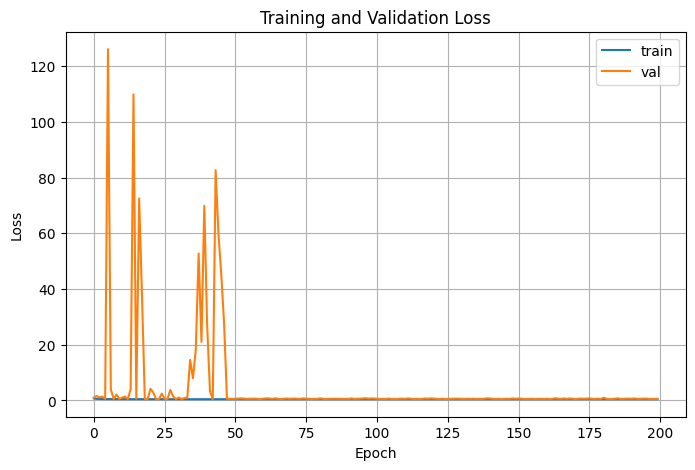

In [13]:
# ----------------- PLOT LOSS CURVES -----------------
h = history
plt.figure(figsize=(8,5))
plt.plot(h['train_loss'], label='train')
plt.plot(h['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# ----------------- LOAD BEST MODEL -----------------
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print('Loaded best model from', MODEL_PATH)

C:\Users\hp\AppData\Local\Temp\ipykernel_18172\233108479.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_PATH, map_location=DEVICE)


Loaded best model from D:/farmland boundary\deeplabv3plus_resnet101_best.pth


In [ ]:
# ===== PREDICT ALL IMAGES =====
predict_images = sorted(glob(os.path.join(PREDICT_IMAGES, '*.jpg')) + glob(os.path.join(PREDICT_IMAGES, '*.png')) + glob(os.path.join(PREDICT_IMAGES, '*.jpeg')))
print(f'🖼️  Total images to predict: {len(predict_images)}')

transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE), 
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), 
    ToTensorV2()
])

with torch.no_grad():
    for image_path in tqdm(predict_images, desc='Predicting'):
        img = cv2.imread(image_path)
        if img is None:
            continue
        orig = img.copy()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        aug = transform(image=img_rgb)
        tensor = aug['image'].unsqueeze(0).to(DEVICE).float()
        out = model(tensor)
        out = torch.sigmoid(out).squeeze().cpu().numpy()
        mask = (out > 0.5).astype(np.uint8) * 255
        
        # morphological cleaning
        kernel = np.ones((3,3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        
        # resize back to original size
        mask_resized = cv2.resize(mask, (orig.shape[1], orig.shape[0]))
        base = os.path.splitext(os.path.basename(image_path))[0]
        out_name = base + '_pred.png'
        out_path = os.path.join(PREDICTION_FOLDER, out_name)
        cv2.imwrite(out_path, mask_resized)
        
        # overlay
        overlay = orig.copy()
        overlay[mask_resized>0] = (0,0,255)  # red overlay in BGR
        cv2.imwrite(os.path.join(OVERLAY_FOLDER, out_name), overlay)

print(f'✅ Predictions saved to {PREDICTION_FOLDER}')

Total images to predict: 268


100%|██████████| 268/268 [01:50<00:00,  2.43it/s]


In [ ]:
# ===== METRICS EVALUATION =====
gt_paths = glob(os.path.join(MASK_FOLDER, '*.png'))
pred_paths = glob(os.path.join(PREDICTION_FOLDER, '*_pred.png'))
pred_map = {normalize_name(os.path.basename(p)): p for p in pred_paths}

ious, dices, precs, recs = [], [], [], []
matched = 0

for gt in gt_paths:
    key = normalize_name(os.path.basename(gt))
    if key not in pred_map:
        continue
    p = pred_map[key]
    g = cv2.imread(gt, 0)
    pr = cv2.imread(p, 0)
    if g is None or pr is None:
        continue
    pr = cv2.resize(pr, (g.shape[1], g.shape[0]))
    g_bin = (g>127).astype(np.uint8)
    p_bin = (pr>127).astype(np.uint8)
    ious.append(iou_numpy(g_bin, p_bin))
    dices.append(dice_numpy(g_bin, p_bin))
    precs.append(precision_numpy(g_bin, p_bin))
    recs.append(recall_numpy(g_bin, p_bin))
    matched += 1

print(f'📊 Matched samples: {matched}')
avg_iou = np.mean(ious) if ious else 0.0
avg_dice = np.mean(dices) if dices else 0.0
avg_prec = np.mean(precs) if precs else 0.0
avg_rec = np.mean(recs) if recs else 0.0

print(f'\n✅ METRICS:')
print(f'   IoU:       {avg_iou:.4f}')
print(f'   Dice:      {avg_dice:.4f}')
print(f'   Precision: {avg_prec:.4f}')
print(f'   Recall:    {avg_rec:.4f}')

Matched samples: 26
IoU: 0.1416, Dice: 0.2372, Prec: 0.3722, Rec: 0.2825


In [17]:
# ----------------- SAMPLE VISUALIZATIONS -----------------
sample_preds = random.sample(pred_paths, min(6, len(pred_paths))) if pred_paths else []
for pp in sample_preds:
    base = os.path.basename(pp)
    orig_name = base.replace('_pred.png', '.png')
    orig_path = os.path.join(PREDICT_IMAGES, orig_name)
    orig = cv2.imread(orig_path)
    if orig is None:
        continue
    gt_path = os.path.join(MASK_FOLDER, base.replace('_pred.png', '.png'))
    gt = cv2.imread(gt_path, 0) if os.path.exists(gt_path) else None
    pred = cv2.imread(pp, 0)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    overlay = orig.copy()
    overlay[pred>127] = [255,0,0]
    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1); plt.imshow(orig); plt.title('Original'); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(pred, cmap='gray'); plt.title('Pred Mask'); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title('Overlay'); plt.axis('off')
    plt.show()